# QPEI Validation Round 2
## Ordinal EFA → Framework Crosswalk → Ordinal/Robust CFA → QPEI Validation

This notebook is the sequel to the preliminary EFA/CFA pipeline.

### Purpose

The first pipeline established that:

- Teacher data are factorable and produced a preliminary 3-factor solution.
- Parent data are factorable and produced a preliminary 3-factor solution.
- Student data are highly factorable but parallel analysis suggested a dominant 1-factor solution.
- Preliminary CFA fit was not yet adequate.

This notebook therefore **does not simply force the previous factors into the final QPEI**.

Instead it performs a second validation round:

1. Audit the master workbook and exact item sets.
2. Inspect missingness and response distributions.
3. Identify likely reverse-coded items from the supplied codebook/crosswalk when available.
4. Construct ordinal association matrices using polychoric correlations where estimable, with a documented fallback.
5. Run parallel analysis and EFA on the ordinal correlation structure.
6. Inspect loadings, communalities, cross-loadings, and factor correlations.
7. Produce a framework-to-empirical crosswalk.
8. Run CFA only on substantively defensible models.
9. Report reliability and convergent evidence.
10. Keep the six-dimensional QPEI as the theory-informed **formative school-level composite**, rather than treating it as one reflective latent factor.
11. Prepare the evidence needed for final QPEI construction.

### Important

The six QPEI dimensions remain:

- D1 Teacher competence and pedagogical practice — 20%
- D2 Curriculum implementation and assessment — 15%
- D3 Learning environment and infrastructure — 15%
- D4 Student learning outcomes and FLN — 20%
- D5 Governance, management, and community support — 15%
- D6 Equity and inclusiveness — 15%

The final QPEI is not declared valid merely because an EFA/CFA fits. Measurement evidence and the conceptual framework must agree.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================================
# 0. SETUP
# ============================================================

!pip -q install factor_analyzer pingouin semopy openpyxl statsmodels scikit-learn scipy

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import json, re, warnings, math
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns

from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
import pingouin as pg
from semopy import Model, calc_stats

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 150)

DATA_PATH = Path("/content/drive/MyDrive/QPEI/QPE_MASTER_Cleaned_IDs_Translated_Analysis.xlsx")
RESULTS_PATH = Path("/content/drive/MyDrive/QPEI/results_round2.json")
OUTPUT_DIR = Path("/content/drive/MyDrive/QPEI/qpei_validation_round2")

TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
LOG_DIR = OUTPUT_DIR / "logs"

for p in [OUTPUT_DIR, TABLE_DIR, FIGURE_DIR, LOG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("="*90)
print("QPEI VALIDATION ROUND 2")
print("="*90)
print("Data:", DATA_PATH)
print("Exists:", DATA_PATH.exists())
print("Results:", RESULTS_PATH)
print("Output:", OUTPUT_DIR)

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Master workbook not found: {DATA_PATH}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 27.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 5.9 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
QPEI VALIDATION ROUND 2
Data: /content/drive/MyDrive/QPEI/QPE_MASTER_Cleaned_IDs_Translated_Analysis.xlsx
Exists: True
Results: /content/drive/MyDrive/QPEI/results_round2.json
Output: /content/drive/MyDrive/QPEI/qpei_validation_round2


In [3]:
# ============================================================
# 1. LOAD WORKBOOK + EXACT ITEM INVENTORY
# ============================================================

xl = pd.ExcelFile(DATA_PATH)
print("Sheets:")
for s in xl.sheet_names:
    print(" •", s)

sheets = {s: pd.read_excel(DATA_PATH, sheet_name=s) for s in xl.sheet_names}

INSTRUMENTS = {
    "Teacher": {"sheet": "Teacher_Survey", "prefix": "tq"},
    "Parent": {"sheet": "Parent_Survey", "prefix": "pq"},
    "Student": {"sheet": "Student_Questionnaire", "prefix": "sq"},
    "Observation": {"sheet": "Classroom_Observation", "prefix": "co"},
    "Environment": {"sheet": "School_Environment", "prefix": "se"},
}

ITEMS = {}

for label, spec in INSTRUMENTS.items():
    df = sheets[spec["sheet"]]
    prefix = spec["prefix"]
    cols = [
        c for c in df.columns
        if re.fullmatch(fr"{prefix}\d+", str(c).strip().lower())
    ]
    cols = sorted(cols, key=lambda x: int(re.search(r"\d+", str(x)).group()))
    ITEMS[label] = cols
    print(f"{label:12s}: {len(cols)} items → {cols}")

TQ_ITEMS = ITEMS["Teacher"]
PQ_ITEMS = ITEMS["Parent"]
SQ_ITEMS = ITEMS["Student"]

assert len(TQ_ITEMS) == 30
assert len(PQ_ITEMS) == 20
assert len(SQ_ITEMS) == 18

inventory = pd.DataFrame([
    {"instrument": k, "sheet": v["sheet"], "n_items": len(ITEMS[k]),
     "items": ", ".join(ITEMS[k])}
    for k, v in INSTRUMENTS.items()
])

display(inventory)
inventory.to_csv(TABLE_DIR / "R2_Table_01_Item_Inventory.csv", index=False)


Sheets:
 • Summary
 • Teacher_Survey
 • Parent_Survey
 • Student_Questionnaire
 • Classroom_Observation
 • School_Environment
 • Codebook
 • Id_Enumerator_School
 • School_Master
 • Translation_Glossary
 • ID_Translation_Report
Teacher     : 30 items → ['tq1', 'tq2', 'tq3', 'tq4', 'tq5', 'tq6', 'tq7', 'tq8', 'tq9', 'tq10', 'tq11', 'tq12', 'tq13', 'tq14', 'tq15', 'tq16', 'tq17', 'tq18', 'tq19', 'tq20', 'tq21', 'tq22', 'tq23', 'tq24', 'tq25', 'tq26', 'tq27', 'tq28', 'tq29', 'tq30']
Parent      : 20 items → ['pq1', 'pq2', 'pq3', 'pq4', 'pq5', 'pq6', 'pq7', 'pq8', 'pq9', 'pq10', 'pq11', 'pq12', 'pq13', 'pq14', 'pq15', 'pq16', 'pq17', 'pq18', 'pq19', 'pq20']
Student     : 18 items → ['sq1', 'sq2', 'sq3', 'sq4', 'sq5', 'sq6', 'sq7', 'sq8', 'sq9', 'sq10', 'sq11', 'sq12', 'sq13', 'sq14', 'sq15', 'sq16', 'sq17', 'sq18']
Observation : 28 items → ['co1', 'co2', 'co3', 'co4', 'co5', 'co6', 'co7', 'co8', 'co9', 'co10', 'co11', 'co12', 'co13', 'co14', 'co15', 'co16', 'co17', 'co18', 'co19', 'co20', 

,instrument,sheet,n_items,items
0,Teacher,Teacher_Survey,30,"tq1, tq2, tq3, tq4, tq5, tq6, tq7, tq8, tq9, t..."
1,Parent,Parent_Survey,20,"pq1, pq2, pq3, pq4, pq5, pq6, pq7, pq8, pq9, p..."
2,Student,Student_Questionnaire,18,"sq1, sq2, sq3, sq4, sq5, sq6, sq7, sq8, sq9, s..."
3,Observation,Classroom_Observation,28,"co1, co2, co3, co4, co5, co6, co7, co8, co9, c..."
4,Environment,School_Environment,11,"se1, se2, se3, se4, se5, se6, se7, se8, se9, s..."


# 2. Response cleaning and missingness

The cleaned master uses:

- 1–5 = substantive response
- 88 = Not Applicable
- 99 = Missing/Unclear

For psychometric analysis, 88 and 99 are treated as missing.

We do **not** alter the original workbook.


In [4]:
# ============================================================
# 2. CLEAN ANALYSIS COPIES
# ============================================================

analysis_sheets = {}

for name, df in sheets.items():
    x = df.copy()

    for col in x.columns:
        if re.fullmatch(r"(tq|pq|sq|co|se)\d+", str(col).strip().lower()):
            x[col] = pd.to_numeric(x[col], errors="coerce")
            x.loc[x[col].isin([88, 99]), col] = np.nan

    analysis_sheets[name] = x

missing_rows = []

for label in ["Teacher", "Parent", "Student"]:
    df = analysis_sheets[INSTRUMENTS[label]["sheet"]]
    for item in ITEMS[label]:
        s = df[item]
        missing_rows.append({
            "instrument": label,
            "item": item,
            "N_total": len(s),
            "N_valid": int(s.notna().sum()),
            "N_missing": int(s.isna().sum()),
            "missing_pct": round(s.isna().mean()*100, 2),
            "mean": s.mean(),
            "sd": s.std(),
            "min": s.min(),
            "max": s.max()
        })

missing_table = pd.DataFrame(missing_rows)
display(missing_table)

missing_table.to_csv(TABLE_DIR / "R2_Table_02_Missingness_Item_Distribution.csv", index=False)


,instrument,item,N_total,N_valid,N_missing,missing_pct,mean,sd,min,max
0,Teacher,tq1,163,162,1,0.61,4.401235,0.700132,2.0,5.0
1,Teacher,tq2,163,162,1,0.61,4.209877,0.672735,1.0,5.0
2,Teacher,tq3,163,162,1,0.61,4.216049,0.930632,2.0,5.0
3,Teacher,tq4,163,162,1,0.61,4.216049,0.702428,2.0,5.0
4,Teacher,tq5,163,162,1,0.61,4.271605,0.796145,2.0,5.0
5,Teacher,tq6,163,162,1,0.61,4.314815,0.791823,1.0,5.0
6,Teacher,tq7,163,162,1,0.61,4.598765,0.625145,2.0,5.0
7,Teacher,tq8,163,161,2,1.23,4.726708,0.474178,3.0,5.0
8,Teacher,tq9,163,160,3,1.84,4.606250,0.583816,2.0,5.0
9,Teacher,tq10,163,162,1,0.61,4.604938,0.561254,3.0,5.0


In [5]:
# ============================================================
# 2A. RESPONSE DISTRIBUTIONS
# ============================================================

distribution_rows = []

for label in ["Teacher", "Parent", "Student"]:
    df = analysis_sheets[INSTRUMENTS[label]["sheet"]]

    for item in ITEMS[label]:
        s = df[item].dropna()

        for value in [1,2,3,4,5]:
            distribution_rows.append({
                "instrument": label,
                "item": item,
                "response": value,
                "n": int((s == value).sum()),
                "percent": round((s == value).mean()*100, 2) if len(s) else np.nan
            })

distribution_table = pd.DataFrame(distribution_rows)
display(distribution_table)

distribution_table.to_csv(
    TABLE_DIR / "R2_Table_03_Response_Distributions.csv",
    index=False
)


,instrument,item,response,n,percent
0,Teacher,tq1,1,0,0.00
1,Teacher,tq1,2,6,3.70
2,Teacher,tq1,3,2,1.23
3,Teacher,tq1,4,75,46.30
4,Teacher,tq1,5,79,48.77
...,...,...,...,...,...
335,Student,sq18,1,2,0.53
336,Student,sq18,2,3,0.79
337,Student,sq18,3,3,0.79
338,Student,sq18,4,67,17.72


# 3. Item wording / translation audit

The statistical model must be interpreted using the actual questionnaire wording.

This cell searches the workbook for likely item-text columns. If a separate translated codebook is available in the workbook, it is displayed here.

**Do not invent translations.** If an item is Bangla and no translated wording exists in the workbook, it is flagged for manual translation rather than silently translated by the statistical pipeline.


In [6]:
# ============================================================
# 3. FIND ITEM TEXT / TRANSLATION COLUMNS
# ============================================================

TEXT_CANDIDATES = [
    "question", "question_text", "item_text", "item",
    "english", "english_translation", "translation",
    "bangla", "bangla_text", "bn", "description", "indicator"
]

text_inventory = []

for label in ["Teacher", "Parent", "Student"]:
    df = sheets[INSTRUMENTS[label]["sheet"]]

    for col in df.columns:
        cl = str(col).strip().lower()

        if any(term in cl for term in TEXT_CANDIDATES):
            text_inventory.append({
                "instrument": label,
                "column": col,
                "dtype": str(df[col].dtype),
                "n_nonmissing": int(df[col].notna().sum())
            })

text_inventory = pd.DataFrame(text_inventory)

display(text_inventory)

text_inventory.to_csv(
    TABLE_DIR / "R2_Table_04_Item_Text_Column_Audit.csv",
    index=False
)

print("\nIf no item-text columns appear above, use the codebook/questionnaire source to build the manual crosswalk.")


""



If no item-text columns appear above, use the codebook/questionnaire source to build the manual crosswalk.


# 4. Reverse-coding audit

Reverse coding must be based on item meaning, not on statistical output.

This notebook therefore provides an explicit table for manual confirmation.

Enter `-1` only for genuinely negatively oriented items. Leave all other items as `1`.

Do not reverse an item merely because its factor loading is negative.


In [7]:
# ============================================================
# 4. EXPLICIT REVERSE-CODE MAP
# ============================================================

REVERSE_CODE_MAP = {
    # Example:
    # "tq12": -1,
    # "pq7": -1,
    # "sq4": -1,
}

reverse_audit = []

for label in ["Teacher", "Parent", "Student"]:
    for item in ITEMS[label]:
        reverse_audit.append({
            "instrument": label,
            "item": item,
            "reverse_code": REVERSE_CODE_MAP.get(item, 1),
            "status": "MANUAL_REVIEW_REQUIRED"
        })

reverse_audit = pd.DataFrame(reverse_audit)
display(reverse_audit)

reverse_audit.to_csv(
    TABLE_DIR / "R2_Table_05_Reverse_Code_Audit.csv",
    index=False
)

print("Current reverse-code entries:", {
    k:v for k,v in REVERSE_CODE_MAP.items()
})


,instrument,item,reverse_code,status
0,Teacher,tq1,1,MANUAL_REVIEW_REQUIRED
1,Teacher,tq2,1,MANUAL_REVIEW_REQUIRED
2,Teacher,tq3,1,MANUAL_REVIEW_REQUIRED
3,Teacher,tq4,1,MANUAL_REVIEW_REQUIRED
4,Teacher,tq5,1,MANUAL_REVIEW_REQUIRED
5,Teacher,tq6,1,MANUAL_REVIEW_REQUIRED
6,Teacher,tq7,1,MANUAL_REVIEW_REQUIRED
7,Teacher,tq8,1,MANUAL_REVIEW_REQUIRED
8,Teacher,tq9,1,MANUAL_REVIEW_REQUIRED
9,Teacher,tq10,1,MANUAL_REVIEW_REQUIRED


Current reverse-code entries: {}


In [8]:
# ============================================================
# 4A. APPLY ONLY EXPLICITLY CONFIRMED REVERSE CODES
# ============================================================

for label in ["Teacher", "Parent", "Student"]:
    df = analysis_sheets[INSTRUMENTS[label]["sheet"]]

    for item in ITEMS[label]:
        if REVERSE_CODE_MAP.get(item, 1) == -1:
            df[item] = 6 - df[item]

print("✓ Explicit reverse codes applied:", [
    k for k,v in REVERSE_CODE_MAP.items() if v == -1
])


✓ Explicit reverse codes applied: []


# 5. Polychoric correlation

Because the questionnaire items are 5-category ordinal responses, the preferred association structure for the measurement analysis is a polychoric correlation matrix.

The implementation below estimates a pairwise polychoric correlation using thresholded bivariate normal likelihood.

If estimation fails for a pair because of sparse categories or numerical instability, the pipeline records the failure and uses Pearson correlation **only for that pair**, with a clear flag.

This is preferable to silently pretending that all Likert items are continuous.


In [9]:
# ============================================================
# 5. POLYCHORIC CORRELATION IMPLEMENTATION
# ============================================================

from scipy.optimize import minimize_scalar
from scipy.stats import multivariate_normal, norm

def _thresholds(x):
    x = np.asarray(x)
    cats = np.sort(np.unique(x[~pd.isna(x)]))
    if len(cats) < 2:
        return cats, np.array([])
    props = np.array([(x <= c).mean() for c in cats[:-1]])
    props = np.clip(props, 1e-5, 1-1e-5)
    return cats, norm.ppf(props)

def polychoric_pair(x, y):
    x = pd.to_numeric(pd.Series(x), errors="coerce")
    y = pd.to_numeric(pd.Series(y), errors="coerce")

    valid = x.notna() & y.notna()
    x = x[valid].to_numpy()
    y = y[valid].to_numpy()

    if len(x) < 30:
        raise ValueError("Too few paired observations.")

    cats_x, tx = _thresholds(x)
    cats_y, ty = _thresholds(y)

    if len(cats_x) < 2 or len(cats_y) < 2:
        raise ValueError("Insufficient category variation.")

    x_edges = np.r_[-np.inf, tx, np.inf]
    y_edges = np.r_[-np.inf, ty, np.inf]

    table = pd.crosstab(x, y).reindex(
        index=cats_x, columns=cats_y, fill_value=0
    ).to_numpy()

    def cell_prob(a, b, rho):
        lo_x, hi_x = x_edges[a], x_edges[a+1]
        lo_y, hi_y = y_edges[b], y_edges[b+1]

        cov = [[1, rho], [rho, 1]]

        def cdf(xx, yy):
            if np.isneginf(xx) or np.isneginf(yy):
                if np.isneginf(xx) and np.isneginf(yy):
                    return 0.0
                if np.isneginf(xx):
                    return norm.cdf(yy)
                if np.isneginf(yy):
                    return norm.cdf(xx)

            if np.isposinf(xx):
                return norm.cdf(yy)
            if np.isposinf(yy):
                return norm.cdf(xx)

            return multivariate_normal.cdf([xx, yy], mean=[0,0], cov=cov)

        p = (
            cdf(hi_x, hi_y)
            - cdf(lo_x, hi_y)
            - cdf(hi_x, lo_y)
            + cdf(lo_x, lo_y)
        )

        return max(float(p), 1e-12)

    def neg_loglik(rho):
        total = 0.0
        for i in range(len(cats_x)):
            for j in range(len(cats_y)):
                n = table[i, j]
                if n > 0:
                    total -= n * np.log(cell_prob(i, j, rho))
        return total

    result = minimize_scalar(
        neg_loglik,
        bounds=(-0.98, 0.98),
        method="bounded",
        options={"xatol": 1e-4}
    )

    if not result.success:
        raise ValueError("Polychoric optimization failed.")

    return float(result.x), int(len(x))


def polychoric_matrix(df, items):
    R = pd.DataFrame(np.eye(len(items)), index=items, columns=items)
    audit = []

    for i, a in enumerate(items):
        for j in range(i+1, len(items)):
            b = items[j]

            try:
                r, n = polychoric_pair(df[a], df[b])
                method = "polychoric"

            except Exception as e:
                pair = pd.concat([df[a], df[b]], axis=1).dropna()
                r = pair.iloc[:,0].corr(pair.iloc[:,1])
                n = len(pair)
                method = "pearson_fallback"

            R.loc[a,b] = r
            R.loc[b,a] = r

            audit.append({
                "item_a": a,
                "item_b": b,
                "correlation": r,
                "n_pair": n,
                "method": method
            })

    return R, pd.DataFrame(audit)


In [10]:
# ============================================================
# 5A. BUILD ORDINAL CORRELATION MATRICES
# ============================================================

ordinal_correlations = {}
ordinal_audits = {}

for label in ["Teacher", "Parent", "Student"]:

    print("\n" + "="*90)
    print(label, "POLYCHORIC MATRIX")
    print("="*90)

    df = analysis_sheets[INSTRUMENTS[label]["sheet"]]

    R, audit = polychoric_matrix(df, ITEMS[label])

    ordinal_correlations[label] = R
    ordinal_audits[label] = audit

    print("Pairwise methods:")
    display(audit["method"].value_counts())

    display(R.round(3))

    R.to_csv(
        TABLE_DIR / f"R2_Ordinal_Correlation_{label}.csv"
    )

    audit.to_csv(
        TABLE_DIR / f"R2_Ordinal_Correlation_Audit_{label}.csv",
        index=False
    )

print("✓ Ordinal correlation matrices generated.")



Teacher POLYCHORIC MATRIX
Pairwise methods:


,count
method,
polychoric,435


,tq1,tq2,tq3,tq4,tq5,tq6,tq7,tq8,tq9,tq10,tq11,tq12,tq13,tq14,tq15,tq16,tq17,tq18,tq19,tq20,tq21,tq22,tq23,tq24,tq25,tq26,tq27,tq28,tq29,tq30
tq1,1.000,0.715,0.767,0.388,0.375,0.530,0.498,0.395,0.553,0.280,0.654,0.443,0.387,0.431,0.335,0.191,0.327,0.246,0.306,0.193,0.189,0.205,0.170,0.262,0.065,0.098,0.377,0.176,0.122,0.340
tq2,0.715,1.000,0.744,0.388,0.361,0.552,0.670,0.437,0.570,0.301,0.439,0.193,0.297,0.259,0.450,0.464,0.248,0.189,0.379,0.253,0.050,0.210,0.002,0.133,0.109,0.028,0.299,0.256,0.090,0.313
tq3,0.767,0.744,1.000,0.427,0.473,0.466,0.486,0.244,0.393,0.095,0.515,0.295,0.638,0.633,0.570,0.306,0.469,0.184,0.577,0.170,0.250,0.186,0.331,0.266,0.159,0.257,0.554,0.374,0.181,0.348
tq4,0.388,0.388,0.427,1.000,0.490,0.296,0.364,0.381,0.264,0.311,0.363,0.279,0.365,0.299,0.408,0.483,0.377,0.240,0.164,0.108,0.129,0.135,-0.055,0.026,0.228,0.132,0.285,0.282,0.241,0.289
tq5,0.375,0.361,0.473,0.490,1.000,0.462,0.367,0.344,0.337,0.440,0.163,0.218,0.188,0.138,0.487,0.285,0.466,0.193,0.255,0.292,-0.180,0.189,-0.037,0.201,0.425,0.076,0.547,0.232,0.222,0.452
tq6,0.530,0.552,0.466,0.296,0.462,1.000,0.622,0.621,0.606,0.485,0.375,0.164,0.050,0.091,0.185,0.239,0.423,0.139,0.486,0.523,-0.110,-0.081,0.019,0.211,0.288,0.190,0.435,0.330,0.317,0.200
tq7,0.498,0.670,0.486,0.364,0.367,0.622,1.000,0.604,0.537,0.501,0.292,0.213,0.060,0.219,0.385,0.288,0.451,0.383,0.647,0.494,0.237,0.166,0.004,0.356,0.244,0.502,0.644,0.532,0.477,0.239
tq8,0.395,0.437,0.244,0.381,0.344,0.621,0.604,1.000,0.576,0.663,0.121,0.253,0.361,0.218,0.214,0.263,0.326,0.202,0.290,0.415,0.331,-0.194,-0.086,0.121,0.141,0.190,0.555,0.451,0.428,0.418
tq9,0.553,0.570,0.393,0.264,0.337,0.606,0.537,0.576,1.000,0.408,0.418,0.117,0.089,0.276,0.278,0.441,0.341,0.210,0.563,0.526,0.098,0.327,0.193,0.331,0.200,0.358,0.513,0.298,0.437,0.553
tq10,0.280,0.301,0.095,0.311,0.440,0.485,0.501,0.663,0.408,1.000,0.285,0.280,-0.008,-0.129,0.496,0.443,0.355,0.279,0.490,0.656,0.328,0.067,-0.081,0.198,0.455,0.397,0.705,0.486,0.617,0.550



Parent POLYCHORIC MATRIX
Pairwise methods:


,count
method,
polychoric,190


,pq1,pq2,pq3,pq4,pq5,pq6,pq7,pq8,pq9,pq10,pq11,pq12,pq13,pq14,pq15,pq16,pq17,pq18,pq19,pq20
pq1,1.000,0.838,0.710,0.433,0.583,0.432,0.453,0.548,0.742,0.617,0.141,0.100,0.077,-0.141,0.202,0.274,0.103,0.150,0.149,0.299
pq2,0.838,1.000,0.719,0.463,0.701,0.559,0.482,0.571,0.791,0.690,0.207,0.027,0.016,-0.094,0.228,0.305,0.188,0.196,0.243,0.377
pq3,0.710,0.719,1.000,0.383,0.678,0.460,0.461,0.451,0.662,0.524,0.192,-0.022,-0.015,-0.004,0.181,0.174,-0.037,0.123,0.094,0.320
pq4,0.433,0.463,0.383,1.000,0.463,0.086,0.396,0.449,0.404,0.529,0.092,0.035,0.253,0.084,0.106,0.274,0.237,0.286,0.244,0.237
pq5,0.583,0.701,0.678,0.463,1.000,0.548,0.493,0.603,0.663,0.654,0.346,0.087,0.262,0.164,0.212,0.402,0.144,0.209,0.352,0.345
pq6,0.432,0.559,0.460,0.086,0.548,1.000,0.487,0.436,0.561,0.388,0.374,0.158,0.131,0.007,0.284,0.319,0.234,0.263,0.213,0.392
pq7,0.453,0.482,0.461,0.396,0.493,0.487,1.000,0.604,0.520,0.506,0.206,0.225,0.172,0.172,0.365,0.200,0.204,0.142,0.167,0.443
pq8,0.548,0.571,0.451,0.449,0.603,0.436,0.604,1.000,0.639,0.534,0.441,0.402,0.293,0.157,0.462,0.361,0.057,0.140,0.240,0.358
pq9,0.742,0.791,0.662,0.404,0.663,0.561,0.520,0.639,1.000,0.740,0.147,0.037,0.111,0.020,0.237,0.445,0.144,0.085,0.230,0.340
pq10,0.617,0.690,0.524,0.529,0.654,0.388,0.506,0.534,0.740,1.000,0.151,0.025,0.066,0.063,0.229,0.241,0.251,0.178,0.354,0.273



Student POLYCHORIC MATRIX
Pairwise methods:


,count
method,
polychoric,153


,sq1,sq2,sq3,sq4,sq5,sq6,sq7,sq8,sq9,sq10,sq11,sq12,sq13,sq14,sq15,sq16,sq17,sq18
sq1,1.000,0.676,0.781,0.609,0.626,0.711,0.682,0.668,0.690,0.633,0.604,0.535,0.690,0.637,0.687,0.675,0.620,0.513
sq2,0.676,1.000,0.711,0.558,0.605,0.656,0.683,0.531,0.531,0.467,0.536,0.370,0.604,0.576,0.534,0.531,0.518,0.571
sq3,0.781,0.711,1.000,0.643,0.560,0.672,0.650,0.722,0.763,0.646,0.566,0.610,0.751,0.744,0.677,0.568,0.575,0.568
sq4,0.609,0.558,0.643,1.000,0.738,0.770,0.749,0.642,0.709,0.549,0.599,0.469,0.647,0.645,0.525,0.668,0.699,0.647
sq5,0.626,0.605,0.560,0.738,1.000,0.727,0.768,0.560,0.629,0.482,0.559,0.321,0.574,0.551,0.535,0.669,0.604,0.563
sq6,0.711,0.656,0.672,0.770,0.727,1.000,0.817,0.644,0.685,0.576,0.628,0.373,0.651,0.610,0.670,0.681,0.682,0.618
sq7,0.682,0.683,0.650,0.749,0.768,0.817,1.000,0.649,0.735,0.543,0.658,0.516,0.711,0.640,0.613,0.737,0.694,0.582
sq8,0.668,0.531,0.722,0.642,0.560,0.644,0.649,1.000,0.806,0.634,0.570,0.583,0.610,0.584,0.546,0.692,0.636,0.571
sq9,0.690,0.531,0.763,0.709,0.629,0.685,0.735,0.806,1.000,0.672,0.648,0.609,0.682,0.667,0.633,0.743,0.622,0.485
sq10,0.633,0.467,0.646,0.549,0.482,0.576,0.543,0.634,0.672,1.000,0.596,0.520,0.606,0.640,0.655,0.589,0.603,0.511


✓ Ordinal correlation matrices generated.


In [11]:
# ============================================================
# 5B. ORDINAL KMO + BARTLETT
# ============================================================

ordinal_factorability = {}

for label, R in ordinal_correlations.items():

    # Factor analyzer accepts a correlation matrix through is_corr_matrix=True.
    # KMO/Bartlett functions may be sensitive to numerical matrices, so use
    # a tiny diagonal regularization only if needed.

    R_use = R.copy()

    try:
        kmo_all, kmo_model = calculate_kmo(R_use)
        bart_chi2, bart_p = calculate_bartlett_sphericity(R_use)

        ordinal_factorability[label] = {
            "KMO": float(kmo_model),
            "Bartlett_chi2": float(bart_chi2),
            "Bartlett_p": float(bart_p),
            "status": "completed"
        }

    except Exception as e:

        ordinal_factorability[label] = {
            "KMO": None,
            "Bartlett_chi2": None,
            "Bartlett_p": None,
            "status": f"failed: {repr(e)}"
        }

ordinal_factorability_table = pd.DataFrame(
    [
        {"instrument": k, **v}
        for k,v in ordinal_factorability.items()
    ]
)

display(ordinal_factorability_table)

ordinal_factorability_table.to_csv(
    TABLE_DIR / "R2_Table_06_Ordinal_Factorability.csv",
    index=False
)


,instrument,KMO,Bartlett_chi2,Bartlett_p,status
0,Teacher,0.345770,1779.544359,1.116176e-161,completed
1,Parent,0.680302,NaN,NaN,completed
2,Student,0.398026,NaN,NaN,completed


# 6. Parallel analysis on the ordinal correlation structure

The number of factors is not chosen from the QPEI framework.

We use:

- observed eigenvalues of the ordinal correlation matrix;
- simulated random ordinal data with the same sample size and category structure;
- 95th percentile random eigenvalues.

The result is interpreted together with factor interpretability and the QPEI conceptual framework.



 Teacher
Suggested factors using mean random: 7
Suggested factors using 95th percentile: 6


,factor,observed_eigenvalue,mean_random,random_95pct
0,1,10.272705,1.904689,2.036723
1,2,3.161862,1.770180,1.856230
2,3,2.371135,1.668807,1.741166
3,4,1.813757,1.585831,1.657684
4,5,1.703270,1.510752,1.575633
5,6,1.510235,1.439676,1.494028
6,7,1.410712,1.378849,1.436676
7,8,1.144305,1.315178,1.366944
8,9,1.111053,1.258002,1.306175
9,10,0.852975,1.204330,1.248101


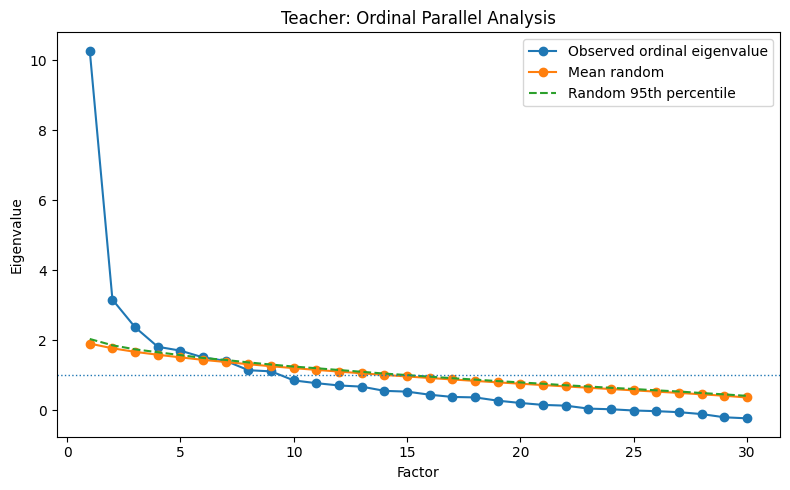


 Parent
Suggested factors using mean random: 3
Suggested factors using 95th percentile: 3


,factor,observed_eigenvalue,mean_random,random_95pct
0,1,7.519823,1.472514,1.560011
1,2,3.570179,1.384162,1.443884
2,3,2.150546,1.319523,1.365936
3,4,1.048807,1.261230,1.306242
4,5,0.774945,1.210426,1.253302
5,6,0.692506,1.164620,1.201868
6,7,0.674399,1.122130,1.161058
7,8,0.634708,1.080512,1.113117
8,9,0.591292,1.040808,1.071251
9,10,0.522540,1.000814,1.032844


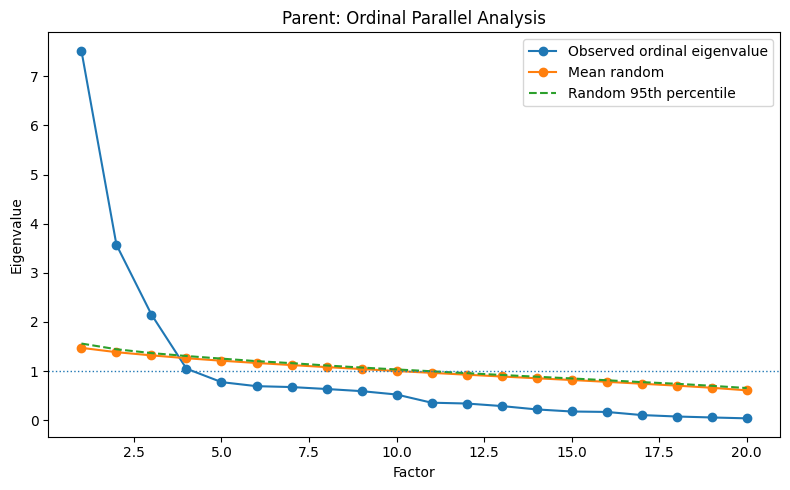


 Student
Suggested factors using mean random: 1
Suggested factors using 95th percentile: 1


,factor,observed_eigenvalue,mean_random,random_95pct
0,1,11.681083,1.398702,1.472584
1,2,1.065458,1.320794,1.371788
2,3,0.805026,1.262597,1.305209
3,4,0.750781,1.210248,1.250063
4,5,0.546820,1.164295,1.200463
5,6,0.528270,1.122028,1.155746
6,7,0.485714,1.080400,1.116340
7,8,0.404126,1.042298,1.071345
8,9,0.324057,1.006986,1.035917
9,10,0.286466,0.968438,0.997852


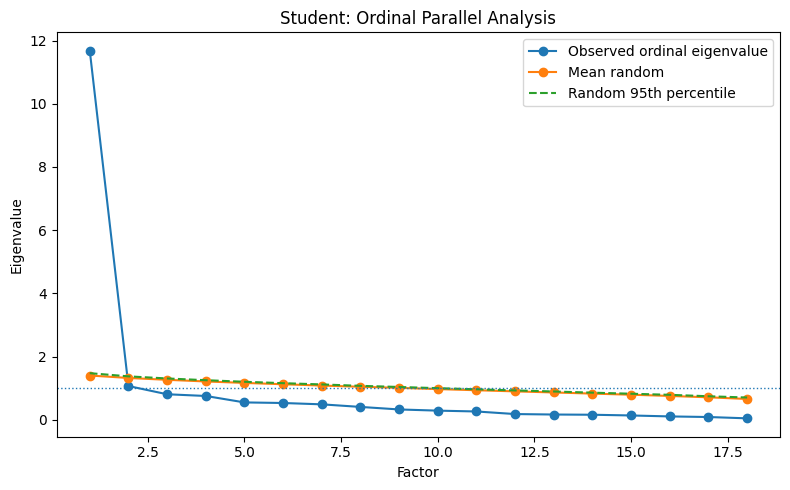

In [12]:
# ============================================================
# 6. PARALLEL ANALYSIS
# ============================================================

def parallel_analysis_from_corr(R, n, n_iter=500, seed=2026):
    observed = np.linalg.eigvalsh(R.values)[::-1]
    p = len(observed)

    rng = np.random.default_rng(seed)
    random_eigs = np.zeros((n_iter, p))

    for b in range(n_iter):
        Z = rng.normal(size=(n, p))
        Rc = np.corrcoef(Z, rowvar=False)
        random_eigs[b] = np.linalg.eigvalsh(Rc)[::-1]

    mean_random = random_eigs.mean(axis=0)
    p95_random = np.percentile(random_eigs, 95, axis=0)

    suggested_mean = int(np.sum(observed > mean_random))
    suggested_95 = int(np.sum(observed > p95_random))

    table = pd.DataFrame({
        "factor": np.arange(1, p+1),
        "observed_eigenvalue": observed,
        "mean_random": mean_random,
        "random_95pct": p95_random
    })

    return table, suggested_mean, suggested_95

parallel2 = {}

for label, R in ordinal_correlations.items():

    n = len(
        analysis_sheets[INSTRUMENTS[label]["sheet"]]
    )

    pa, k_mean, k_95 = parallel_analysis_from_corr(
        R, n
    )

    parallel2[label] = {
        "table": pa,
        "suggested_mean": k_mean,
        "suggested_95": k_95
    }

    print("\n", label)
    print("Suggested factors using mean random:", k_mean)
    print("Suggested factors using 95th percentile:", k_95)
    display(pa)

    pa.to_csv(
        TABLE_DIR / f"R2_Table_07_Parallel_Analysis_{label}.csv",
        index=False
    )

    plt.figure(figsize=(8,5))
    plt.plot(
        pa["factor"],
        pa["observed_eigenvalue"],
        marker="o",
        label="Observed ordinal eigenvalue"
    )
    plt.plot(
        pa["factor"],
        pa["mean_random"],
        marker="o",
        label="Mean random"
    )
    plt.plot(
        pa["factor"],
        pa["random_95pct"],
        linestyle="--",
        label="Random 95th percentile"
    )
    plt.axhline(1, linestyle=":", linewidth=1)
    plt.xlabel("Factor")
    plt.ylabel("Eigenvalue")
    plt.title(f"{label}: Ordinal Parallel Analysis")
    plt.legend()
    plt.tight_layout()

    fig = FIGURE_DIR / f"R2_Figure_01_Parallel_{label}.png"
    plt.savefig(fig, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


# 7. Ordinal EFA

The preferred extraction is Principal Axis Factoring on the ordinal association matrix, with oblimin rotation because educational quality dimensions are expected to correlate.

The primary factor count is the **95th-percentile parallel-analysis result**, but the mean-random result is also retained.

If the two disagree, the decision is documented rather than hidden.


In [14]:
import pandas as pd
import numpy as np
from factor_analyzer import FactorAnalyzer
from pathlib import Path

# Placeholder for variables that are assumed to be defined in previous cells
ordinal_correlations = globals().get('ordinal_correlations', {})
parallel2 = globals().get('parallel2', {})
TABLE_DIR = globals().get('TABLE_DIR', Path('.'))

ordinal_efa = {}

for label, R in ordinal_correlations.items():

    n_mean = parallel2[label]["suggested_mean"]
    n_95 = parallel2[label]["suggested_95"]

    # Conservative starting choice: 95th percentile PA
    n_factors = max(1, n_95)

    # Avoid an impossible model
    n_factors = min(n_factors, len(R.columns)-1)

    fa = FactorAnalyzer(
        n_factors=n_factors,
        rotation="oblimin",
        method="minres", # Changed from "principal" to "minres"
        is_corr_matrix=True
    )

    fa.fit(R)

    loadings = pd.DataFrame(
        fa.loadings_,
        index=R.columns,
        columns=[f"Factor_{i+1}" for i in range(n_factors)]
    )

    communalities = pd.DataFrame({
        "item": R.columns,
        "communality": fa.get_communalities(),
        "uniqueness": fa.get_uniquenesses()
    })

    phi = (
        pd.DataFrame(
            fa.phi_,
            index=loadings.columns,
            columns=loadings.columns
        )
        if fa.phi_ is not None else pd.DataFrame()
    )

    ordinal_efa[label] = {
        "n_factors": n_factors,
        "loadings": loadings,
        "communalities": communalities,
        "factor_correlations": phi
    }

    print("\n" + "="*90)
    print(label, "ORDINAL EFA")
    print("Factors:", n_factors)
    print("="*90)

    display(loadings.round(3))
    display(communalities.round(3))

    print("Factor correlations:")
    display(phi.round(3))

    loadings.to_csv(
        TABLE_DIR / f"R2_Table_08_Ordinal_EFA_Loadings_{label}.csv"
    )

    communalities.to_csv(
        TABLE_DIR / f"R2_Table_09_Ordinal_EFA_Communalities_{label}.csv",
        index=False
    )

    phi.to_csv(
        TABLE_DIR / f"R2_Table_10_Ordinal_EFA_Factor_Correlations_{label}.csv"
    )


Teacher ORDINAL EFA
Factors: 6


,Factor_1,Factor_2,Factor_3,Factor_4,Factor_5,Factor_6
tq1,-0.109,0.517,0.071,0.454,0.007,0.285
tq2,-0.125,0.611,0.282,0.304,-0.095,-0.017
tq3,-0.033,0.378,0.188,0.736,0.115,0.048
tq4,-0.056,0.078,0.549,0.123,-0.154,0.221
tq5,-0.033,0.262,0.477,-0.005,-0.001,0.070
tq6,0.028,0.870,-0.002,-0.086,0.025,0.041
tq7,0.302,0.619,0.043,0.049,0.121,0.011
tq8,0.456,0.478,0.045,-0.136,-0.361,0.338
tq9,0.238,0.537,0.101,0.145,0.101,-0.058
tq10,0.358,0.261,0.415,-0.473,0.022,0.273


,item,communality,uniqueness
0,tq1,0.571,0.429
1,tq2,0.570,0.430
2,tq3,0.737,0.263
3,tq4,0.398,0.602
4,tq5,0.302,0.698
5,tq6,0.767,0.233
6,tq7,0.493,0.507
7,tq8,0.701,0.299
8,tq9,0.389,0.611
9,tq10,0.667,0.333


Factor correlations:


,Factor_1,Factor_2,Factor_3,Factor_4,Factor_5,Factor_6
Factor_1,1.000,0.040,0.268,0.245,0.176,0.376
Factor_2,0.040,1.000,0.142,0.027,0.160,0.183
Factor_3,0.268,0.142,1.000,0.132,0.244,0.396
Factor_4,0.245,0.027,0.132,1.000,0.064,0.195
Factor_5,0.176,0.160,0.244,0.064,1.000,0.238
Factor_6,0.376,0.183,0.396,0.195,0.238,1.000


...


Student ORDINAL EFA
Factors: 1


,Factor_1
sq1,0.822
sq2,0.716
sq3,0.834
sq4,0.810
sq5,0.749
sq6,0.835
sq7,0.854
sq8,0.791
sq9,0.844
sq10,0.734


,item,communality,uniqueness
0,sq1,0.676,0.324
1,sq2,0.512,0.488
2,sq3,0.696,0.304
3,sq4,0.656,0.344
4,sq5,0.562,0.438
5,sq6,0.697,0.303
6,sq7,0.729,0.271
7,sq8,0.626,0.374
8,sq9,0.713,0.287
9,sq10,0.539,0.461


Factor correlations:


""


In [15]:
# ============================================================
# 7A. LOADING DIAGNOSTICS / CROSS-LOADING FLAGS
# ============================================================

loading_flags = []

for label, result in ordinal_efa.items():

    L = result["loadings"]

    for item in L.index:

        abs_load = L.loc[item].abs().sort_values(ascending=False)

        primary_factor = abs_load.index[0]
        primary = abs_load.iloc[0]

        secondary = (
            abs_load.iloc[1]
            if len(abs_load) > 1 else 0
        )

        loading_flags.append({
            "instrument": label,
            "item": item,
            "primary_factor": primary_factor,
            "primary_loading": float(primary),
            "secondary_loading": float(secondary),
            "loading_gap": float(primary-secondary),
            "cross_loading_flag": bool(
                primary >= 0.40 and
                secondary >= 0.30 and
                (primary-secondary) < 0.20
            ),
            "weak_primary_flag": bool(primary < 0.40)
        })

loading_flags = pd.DataFrame(loading_flags)

display(loading_flags)

loading_flags.to_csv(
    TABLE_DIR / "R2_Table_11_EFA_Loading_Flags.csv",
    index=False
)


,instrument,item,primary_factor,primary_loading,secondary_loading,loading_gap,cross_loading_flag,weak_primary_flag
0,Teacher,tq1,Factor_2,0.516748,0.453906,0.062842,True,False
1,Teacher,tq2,Factor_2,0.610812,0.303777,0.307034,False,False
2,Teacher,tq3,Factor_4,0.736493,0.377525,0.358968,False,False
3,Teacher,tq4,Factor_3,0.549087,0.220625,0.328461,False,False
4,Teacher,tq5,Factor_3,0.476546,0.261694,0.214851,False,False
5,Teacher,tq6,Factor_2,0.870037,0.085792,0.784245,False,False
6,Teacher,tq7,Factor_2,0.619132,0.301991,0.317141,False,False
7,Teacher,tq8,Factor_2,0.477547,0.455773,0.021774,True,False
8,Teacher,tq9,Factor_2,0.536705,0.237883,0.298822,False,False
9,Teacher,tq10,Factor_4,0.473141,0.415262,0.057880,True,False


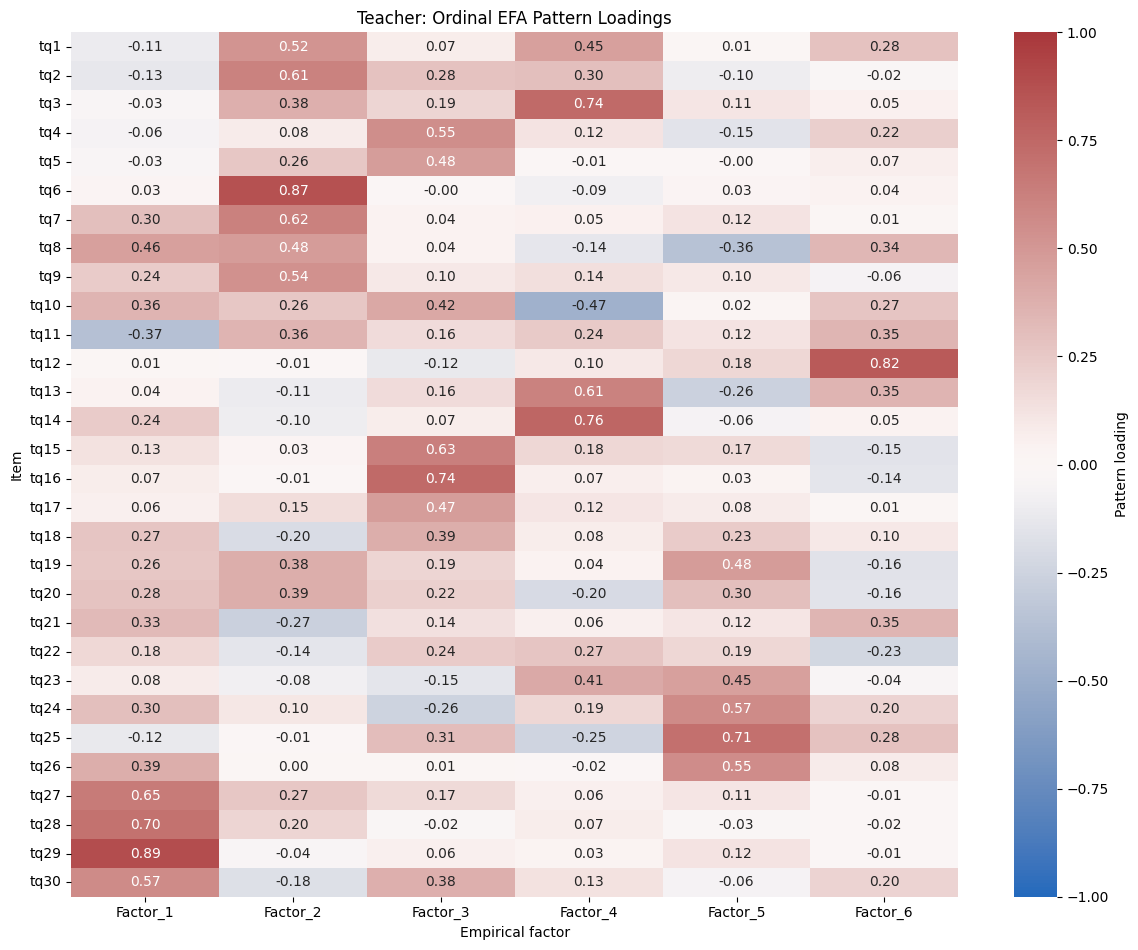

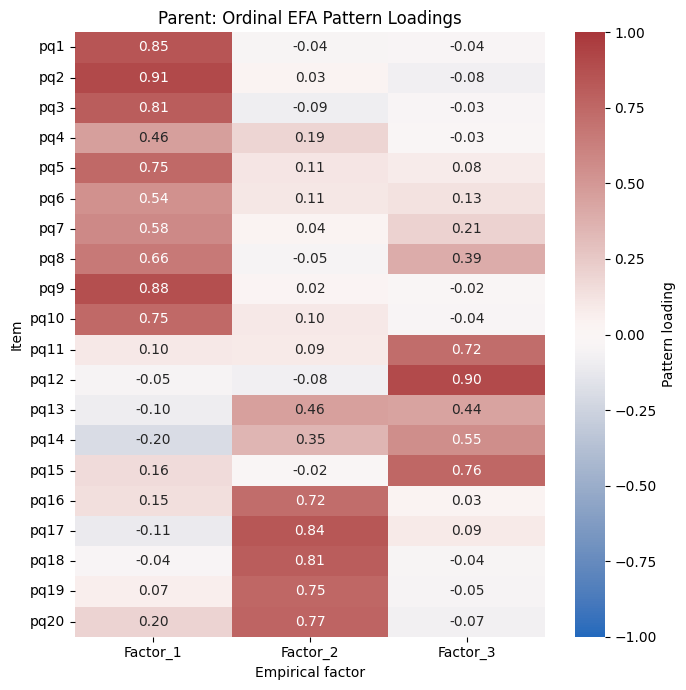

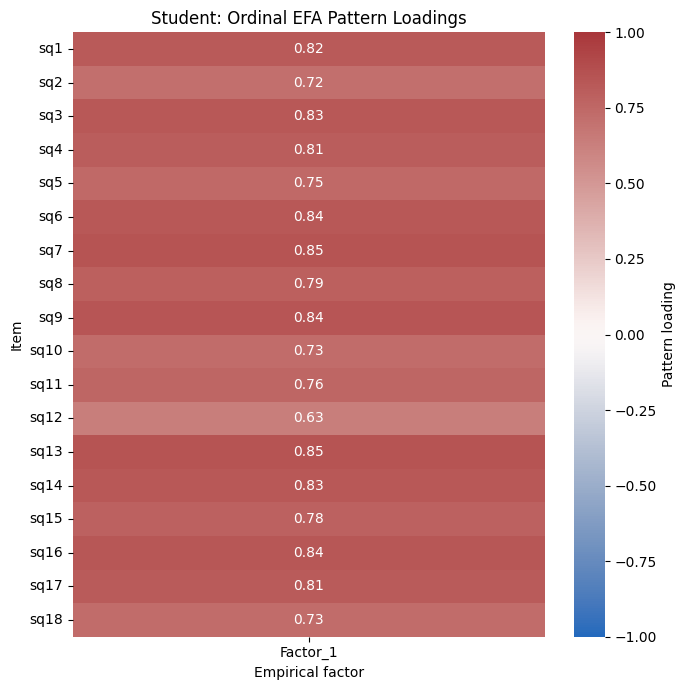

In [16]:
# ============================================================
# 7B. EFA HEATMAPS
# ============================================================

for label, result in ordinal_efa.items():

    L = result["loadings"]

    plt.figure(
        figsize=(
            max(7, L.shape[1]*2),
            max(7, L.shape[0]*0.32)
        )
    )

    sns.heatmap(
        L,
        annot=True,
        fmt=".2f",
        center=0,
        cmap="vlag",
        vmin=-1,
        vmax=1,
        cbar_kws={"label": "Pattern loading"}
    )

    plt.title(f"{label}: Ordinal EFA Pattern Loadings")
    plt.xlabel("Empirical factor")
    plt.ylabel("Item")
    plt.tight_layout()

    fig = FIGURE_DIR / f"R2_Figure_02_EFA_Loadings_{label}.png"
    plt.savefig(fig, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


# 8. Framework crosswalk

This is the bridge between psychometrics and QPEI.

The empirical factors are **not automatically renamed as D1–D6**.

Instead, every item is classified using:

1. questionnaire wording;
2. empirical factor;
3. primary loading;
4. cross-loading behaviour;
5. QPEI indicator definition;
6. respondent/source;
7. substantive rationale.

The resulting table becomes the evidence trail for retaining, revising, or dropping candidate indicators.


In [17]:
# ============================================================
# 8. FRAMEWORK TEMPLATE
# ============================================================

QPEI_FRAMEWORK = {
    "D1": {
        "name": "Teacher competence and pedagogical practice",
        "weight": 0.20,
        "indicators": [
            "Lesson planning",
            "Student-centred teaching",
            "Teaching-learning materials",
            "Support for slow learners",
            "Feedback"
        ]
    },
    "D2": {
        "name": "Curriculum implementation and assessment",
        "weight": 0.15,
        "indicators": [
            "Learning outcome clarity",
            "Teacher guide use",
            "Continuous assessment",
            "Use of assessment results"
        ]
    },
    "D3": {
        "name": "Learning environment and infrastructure",
        "weight": 0.15,
        "indicators": [
            "Safety",
            "WASH",
            "Light/ventilation",
            "Seating",
            "Playground",
            "Classroom readiness"
        ]
    },
    "D4": {
        "name": "Student learning outcomes and FLN",
        "weight": 0.20,
        "indicators": [
            "Reading",
            "Writing",
            "Numeracy",
            "Participation",
            "Confidence",
            "Aspiration"
        ]
    },
    "D5": {
        "name": "Governance, management, and community support",
        "weight": 0.15,
        "indicators": [
            "Leadership",
            "Supervision",
            "Monitoring",
            "Parent engagement",
            "Data use"
        ]
    },
    "D6": {
        "name": "Equity and inclusiveness",
        "weight": 0.15,
        "indicators": [
            "Equal participation",
            "Slow learner support",
            "Gender sensitivity",
            "Support for disadvantaged learners"
        ]
    }
}

framework_rows = []

for d, spec in QPEI_FRAMEWORK.items():
    for ind in spec["indicators"]:
        framework_rows.append({
            "dimension": d,
            "dimension_name": spec["name"],
            "weight": spec["weight"],
            "indicator": ind
        })

framework_table = pd.DataFrame(framework_rows)

display(framework_table)

framework_table.to_csv(
    TABLE_DIR / "R2_Table_12_QPEI_Framework.csv",
    index=False
)


,dimension,dimension_name,weight,indicator
0,D1,Teacher competence and pedagogical practice,0.20,Lesson planning
1,D1,Teacher competence and pedagogical practice,0.20,Student-centred teaching
2,D1,Teacher competence and pedagogical practice,0.20,Teaching-learning materials
3,D1,Teacher competence and pedagogical practice,0.20,Support for slow learners
4,D1,Teacher competence and pedagogical practice,0.20,Feedback
5,D2,Curriculum implementation and assessment,0.15,Learning outcome clarity
6,D2,Curriculum implementation and assessment,0.15,Teacher guide use
7,D2,Curriculum implementation and assessment,0.15,Continuous assessment
8,D2,Curriculum implementation and assessment,0.15,Use of assessment results
9,D3,Learning environment and infrastructure,0.15,Safety


In [18]:
# ============================================================
# 8A. EMPIRICAL CROSSWALK TEMPLATE
# ============================================================

crosswalk_columns = [
    "instrument",
    "item",
    "translation_or_item_text",
    "empirical_factor",
    "primary_loading",
    "cross_loading_flag",
    "qpei_dimension",
    "qpei_indicator",
    "source_of_indicator",
    "retain",
    "decision",
    "rationale"
]

crosswalk = pd.DataFrame(
    columns=crosswalk_columns
)

for label in ["Teacher", "Parent", "Student"]:

    L = ordinal_efa[label]["loadings"]

    for item in L.index:

        abs_load = L.loc[item].abs().sort_values(
            ascending=False
        )

        primary_factor = abs_load.index[0]
        primary_loading = abs_load.iloc[0]

        secondary = abs_load.iloc[1] if len(abs_load) > 1 else 0

        crosswalk.loc[len(crosswalk)] = {
            "instrument": label,
            "item": item,
            "translation_or_item_text": "",
            "empirical_factor": primary_factor,
            "primary_loading": round(float(primary_loading), 3),
            "cross_loading_flag": bool(
                primary_loading >= .40 and
                secondary >= .30 and
                primary_loading-secondary < .20
            ),
            "qpei_dimension": "",
            "qpei_indicator": "",
            "source_of_indicator": "",
            "retain": "",
            "decision": "MANUAL_REVIEW",
            "rationale": ""
        }

display(crosswalk)

crosswalk.to_csv(
    TABLE_DIR / "R2_Table_13_Empirical_QPEI_Crosswalk_REVIEW.csv",
    index=False
)

print("IMPORTANT: complete this table after reviewing item wording.")


,instrument,item,translation_or_item_text,empirical_factor,primary_loading,cross_loading_flag,qpei_dimension,qpei_indicator,source_of_indicator,retain,decision,rationale
0,Teacher,tq1,,Factor_2,0.517,True,,,,,MANUAL_REVIEW,
1,Teacher,tq2,,Factor_2,0.611,False,,,,,MANUAL_REVIEW,
2,Teacher,tq3,,Factor_4,0.736,False,,,,,MANUAL_REVIEW,
3,Teacher,tq4,,Factor_3,0.549,False,,,,,MANUAL_REVIEW,
4,Teacher,tq5,,Factor_3,0.477,False,,,,,MANUAL_REVIEW,
5,Teacher,tq6,,Factor_2,0.870,False,,,,,MANUAL_REVIEW,
6,Teacher,tq7,,Factor_2,0.619,False,,,,,MANUAL_REVIEW,
7,Teacher,tq8,,Factor_2,0.478,True,,,,,MANUAL_REVIEW,
8,Teacher,tq9,,Factor_2,0.537,False,,,,,MANUAL_REVIEW,
9,Teacher,tq10,,Factor_4,0.473,True,,,,,MANUAL_REVIEW,


IMPORTANT: complete this table after reviewing item wording.


# 9. Reliability on ordinal factor indicators

Cronbach's alpha is retained for comparability with the previous analysis, but the ordinal analysis should not rely on alpha alone.

Where a factor has a defensible set of items, report:

- alpha
- corrected item-total correlation
- item count
- factor loadings
- factor coherence

Omega/ordinal omega can be added after the final factor model is fixed.


In [19]:
# ============================================================
# 9. RELIABILITY OF EFA FACTORS
# ============================================================

reliability_rows = []

for label, result in ordinal_efa.items():

    L = result["loadings"]
    df = analysis_sheets[INSTRUMENTS[label]["sheet"]]

    for factor in L.columns:

        abs_primary = L[factor].abs()

        if len(L.columns) > 1:
            abs_other = L.drop(columns=[factor]).abs().max(axis=1)
        else:
            abs_other = pd.Series(0, index=L.index)

        selected = L.index[
            (abs_primary >= .40) &
            ((abs_primary - abs_other) >= .10)
        ].tolist()

        if len(selected) >= 2:

            try:
                alpha, alpha_ci = pg.cronbach_alpha(
                    data=df[selected].dropna()
                )

            except Exception:
                alpha = np.nan
                alpha_ci = [np.nan, np.nan]

            reliability_rows.append({
                "instrument": label,
                "factor": factor,
                "n_items": len(selected),
                "items": ", ".join(selected),
                "alpha": alpha,
                "alpha_ci_low": alpha_ci[0],
                "alpha_ci_high": alpha_ci[1]
            })

reliability_r2 = pd.DataFrame(reliability_rows)

display(reliability_r2)

reliability_r2.to_csv(
    TABLE_DIR / "R2_Table_14_Reliability.csv",
    index=False
)


,instrument,factor,n_items,items,alpha,alpha_ci_low,alpha_ci_high
0,Teacher,Factor_1,4,"tq27, tq28, tq29, tq30",0.699720,0.616,0.769
1,Teacher,Factor_2,4,"tq2, tq6, tq7, tq9",0.745113,0.674,0.804
2,Teacher,Factor_3,5,"tq4, tq5, tq15, tq16, tq17",0.694576,0.613,0.764
3,Teacher,Factor_4,3,"tq3, tq13, tq14",0.776964,0.710,0.830
4,Teacher,Factor_5,3,"tq24, tq25, tq26",0.519648,0.374,0.636
5,Parent,Factor_1,10,"pq1, pq2, pq3, pq4, pq5, pq6, pq7, pq8, pq9, pq10",0.837953,0.809,0.864
6,Parent,Factor_2,5,"pq16, pq17, pq18, pq19, pq20",0.722002,0.670,0.768
7,Parent,Factor_3,4,"pq11, pq12, pq14, pq15",0.706004,0.648,0.756
8,Student,Factor_1,18,"sq1, sq2, sq3, sq4, sq5, sq6, sq7, sq8, sq9, s...",0.945805,0.937,0.954


# 10. CFA model specification

CFA should only be fitted after the EFA and substantive crosswalk are reviewed.

This notebook generates a **candidate model** from the ordinal EFA, but it does not automatically claim that candidate to be the final validated model.

For the current Python environment, semopy is used as the available CFA engine. Because semopy's standard workflow does not provide a full WLSMV categorical estimator equivalent to specialist ordinal SEM software, the CFA output is labelled accordingly.

If the final manuscript requires strict ordinal CFA, the final candidate model should also be replicated in an ordinal-SEM implementation such as R/lavaan with an appropriate categorical estimator.


In [20]:
# ============================================================
# 10. GENERATE CANDIDATE CFA SYNTAX
# ============================================================

CFA_MODELS = {}

for label, result in ordinal_efa.items():

    L = result["loadings"]
    lines = []

    for factor in L.columns:

        abs_primary = L[factor].abs()

        if len(L.columns) > 1:
            abs_other = L.drop(columns=[factor]).abs().max(axis=1)
        else:
            abs_other = pd.Series(0, index=L.index)

        selected = L.index[
            (abs_primary >= .40) &
            ((abs_primary - abs_other) >= .10)
        ].tolist()

        # CFA factor needs at least 3 indicators for a defensible basic model
        if len(selected) >= 3:
            lines.append(
                f"{factor} =~ " + " + ".join(selected)
            )

    CFA_MODELS[label] = "\n".join(lines)

    print("\n" + "="*90)
    print(label)
    print(CFA_MODELS[label] if CFA_MODELS[label] else "No candidate factor met the 3-indicator rule.")

    (LOG_DIR / f"R2_CFA_Candidate_{label}.txt").write_text(
        CFA_MODELS[label],
        encoding="utf-8"
    )



Teacher
Factor_1 =~ tq27 + tq28 + tq29 + tq30
Factor_2 =~ tq2 + tq6 + tq7 + tq9
Factor_3 =~ tq4 + tq5 + tq15 + tq16 + tq17
Factor_4 =~ tq3 + tq13 + tq14
Factor_5 =~ tq24 + tq25 + tq26

Parent
Factor_1 =~ pq1 + pq2 + pq3 + pq4 + pq5 + pq6 + pq7 + pq8 + pq9 + pq10
Factor_2 =~ pq16 + pq17 + pq18 + pq19 + pq20
Factor_3 =~ pq11 + pq12 + pq14 + pq15

Student
Factor_1 =~ sq1 + sq2 + sq3 + sq4 + sq5 + sq6 + sq7 + sq8 + sq9 + sq10 + sq11 + sq12 + sq13 + sq14 + sq15 + sq16 + sq17 + sq18


In [21]:
# ============================================================
# 10A. FIT CANDIDATE CFA
# ============================================================

cfa_r2 = {}

for label, syntax in CFA_MODELS.items():

    if not syntax.strip():
        continue

    df = analysis_sheets[INSTRUMENTS[label]["sheet"]]

    used_items = sorted(
        set(re.findall(r"\b(?:tq|pq|sq)\d+\b", syntax)),
        key=lambda x: int(re.search(r"\d+", x).group())
    )

    X = df[used_items].dropna()

    print("\n" + "="*90)
    print(label, "CFA")
    print("N complete:", len(X))
    print("Items:", used_items)

    if len(X) < max(100, 10 * len(used_items)):
        print("⚠ WARNING: candidate CFA may be underpowered.")

    try:

        model = Model(syntax)
        model.fit(X)

        fit = calc_stats(model)

        cfa_r2[label] = {
            "syntax": syntax,
            "N": len(X),
            "items": used_items,
            "fit": fit,
            "estimator_note": (
                "semopy standard continuous-variable CFA; "
                "not equivalent to WLSMV ordinal CFA"
            )
        }

        display(fit)

        fit.to_csv(
            TABLE_DIR / f"R2_Table_15_CFA_Fit_{label}.csv"
        )

    except Exception as e:

        cfa_r2[label] = {
            "syntax": syntax,
            "error": repr(e)
        }

        print("CFA failed:", repr(e))



Teacher CFA
N complete: 154
Items: ['tq2', 'tq3', 'tq4', 'tq5', 'tq6', 'tq7', 'tq9', 'tq13', 'tq14', 'tq15', 'tq16', 'tq17', 'tq24', 'tq25', 'tq26', 'tq27', 'tq28', 'tq29', 'tq30']
⚠ WARNING: candidate CFA may be underpowered.


,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,142,171,238.049834,7.909665e-07,924.363047,0.872505,0.742471,0.689878,0.742471,0.846468,0.06649,92.908444,238.682169,1.545778



Parent CFA
N complete: 294
Items: ['pq1', 'pq2', 'pq3', 'pq4', 'pq5', 'pq6', 'pq7', 'pq8', 'pq9', 'pq10', 'pq11', 'pq12', 'pq14', 'pq15', 'pq16', 'pq17', 'pq18', 'pq19', 'pq20']


,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,149,171,533.275543,0.0,1913.850495,0.779513,0.72136,0.680218,0.72136,0.746958,0.09382,78.372275,229.399046,1.813862



Student CFA
N complete: 368
Items: ['sq1', 'sq2', 'sq3', 'sq4', 'sq5', 'sq6', 'sq7', 'sq8', 'sq9', 'sq10', 'sq11', 'sq12', 'sq13', 'sq14', 'sq15', 'sq16', 'sq17', 'sq18']


,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,135,153,733.934824,0.0,4620.367893,0.865931,0.841152,0.819973,0.841152,0.848055,0.109949,68.011224,208.70221,1.994388


In [22]:
# ============================================================
# 10B. CFA STANDARDIZED LOADINGS
# ============================================================

for label, result in cfa_r2.items():

    if "error" in result:
        continue

    model = Model(result["syntax"])

    try:
        model.fit(
            analysis_sheets[
                INSTRUMENTS[label]["sheet"]
            ][result["items"]].dropna()
        )

        estimates = model.inspect(
            std_est=True
        )

        print("\n", label, "STANDARDIZED ESTIMATES")
        display(estimates)

        estimates.to_csv(
            TABLE_DIR / f"R2_Table_16_CFA_Standardized_{label}.csv",
            index=False
        )

    except Exception as e:
        print(label, "standardized solution failed:", repr(e))



 Teacher STANDARDIZED ESTIMATES


,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,tq27,~,Factor_1,1.000000,0.711504,-,-,-
1,tq28,~,Factor_1,1.217367,0.651839,0.191354,6.361855,0.0
2,tq29,~,Factor_1,0.780894,0.650694,0.122888,6.354533,0.0
3,tq30,~,Factor_1,0.504504,0.482430,0.101141,4.988139,0.000001
4,tq2,~,Factor_2,1.000000,0.642909,-,-,-
5,tq6,~,Factor_2,1.293062,0.655530,0.205839,6.281924,0.0
6,tq7,~,Factor_2,1.003189,0.683475,0.155338,6.458124,0.0
7,tq9,~,Factor_2,0.751932,0.556966,0.13528,5.558322,0.0
8,tq4,~,Factor_3,1.000000,0.567635,-,-,-
9,tq5,~,Factor_3,1.225662,0.615283,0.22288,5.499193,0.0



 Parent STANDARDIZED ESTIMATES


,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,pq1,~,Factor_1,1.000000,0.660069,-,-,-
1,pq2,~,Factor_1,1.261824,0.805419,0.10924,11.550916,0.0
2,pq3,~,Factor_1,1.381396,0.769061,0.123836,11.155019,0.0
3,pq4,~,Factor_1,0.786864,0.475925,0.107008,7.353291,0.0
4,pq5,~,Factor_1,1.220573,0.728498,0.114247,10.683624,0.0
5,pq6,~,Factor_1,1.001144,0.480311,0.135004,7.415661,0.0
6,pq7,~,Factor_1,1.248661,0.585459,0.140821,8.86701,0.0
7,pq8,~,Factor_1,1.038966,0.431160,0.154864,6.708902,0.0
8,pq9,~,Factor_1,0.756545,0.576925,0.086437,8.752526,0.0
9,pq10,~,Factor_1,0.772218,0.459311,0.108522,7.115756,0.0



 Student STANDARDIZED ESTIMATES


,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sq1,~,Factor_1,1.000000,0.735571,-,-,-
1,sq2,~,Factor_1,1.102140,0.631462,0.09039,12.19315,0.0
2,sq3,~,Factor_1,1.178709,0.817196,0.07318,16.106992,0.0
3,sq4,~,Factor_1,1.454663,0.749829,0.099227,14.659948,0.0
4,sq5,~,Factor_1,1.339498,0.676161,0.102142,13.11412,0.0
5,sq6,~,Factor_1,1.291888,0.802538,0.08182,15.7893,0.0
6,sq7,~,Factor_1,1.495689,0.804267,0.094504,15.826683,0.0
7,sq8,~,Factor_1,1.250630,0.660887,0.09772,12.798043,0.0
8,sq9,~,Factor_1,1.377475,0.796289,0.087993,15.654343,0.0
9,sq10,~,Factor_1,1.290269,0.650015,0.102615,12.573934,0.0


# 11. QPEI is not one reflective CFA factor

Do **not** fit:

`QPEI =~ D1 + D2 + D3 + D4 + D5 + D6`

and call failure/fit the validity of the index.

The methodology defines QPEI as a weighted, school-level, theory-informed composite. Its dimensions are conceptually distinct contributors to quality.

The correct validation question is whether:

- the six dimensions are substantively defensible;
- indicators adequately represent each dimension;
- respondent sources triangulate where appropriate;
- aggregation to school level is defensible;
- the composite is stable under weighting sensitivity.


In [23]:
# ============================================================
# 12. SCHOOL-LEVEL RESPONDENT COUNTS
# ============================================================

school_counts = {}

for label in ["Teacher", "Parent", "Student"]:

    df = analysis_sheets[
        INSTRUMENTS[label]["sheet"]
    ]

    if "school_id" in df.columns:

        counts = (
            df["school_id"]
            .value_counts()
            .rename_axis("school_id")
            .reset_index(name="n_respondents")
        )

        school_counts[label] = counts

        print("\n", label)
        display(counts)

        counts.to_csv(
            TABLE_DIR /
            f"R2_School_Respondent_Counts_{label}.csv",
            index=False
        )



 Teacher


,school_id,n_respondents
0,S04,9
1,S03,6
2,S08,6
3,S25,5
4,S21,5
5,S22,5
6,S27,5
7,S26,5
8,S24,5
9,S23,5



 Parent


,school_id,n_respondents
0,S04,12
1,S03,11
2,S25,10
3,S26,10
4,S23,10
5,S22,10
6,S28,10
7,S21,10
8,S19,10
9,S24,10



 Student


,school_id,n_respondents
0,S26,13
1,S25,12
2,S27,12
3,S28,12
4,S21,12
5,S22,12
6,S23,12
7,S24,12
8,S04,12
9,S03,12


# 13. Measurement-to-framework decision rules

The final indicator decision should follow these rules:

### Retain
- strong or acceptable loading;
- no problematic cross-loading;
- substantive match with the QPEI indicator;
- sufficient response variability;
- no serious missingness problem.

### Review
- moderate loading;
- cross-loading;
- unusual response distribution;
- weak but theoretically important indicator;
- source-specific indicator.

### Remove only with justification
- near-zero variance;
- severe missingness;
- clear wording/data problem;
- strong empirical redundancy;
- no defensible conceptual role.

A weak correlation is **not by itself sufficient reason to remove a formative QPEI indicator**.


In [24]:
# ============================================================
# 13. AUTOMATIC ITEM DECISION FLAGS
# ============================================================

decision_flags = []

for label in ["Teacher", "Parent", "Student"]:

    diag = missing_table[
        missing_table["instrument"] == label
    ].set_index("item")

    L = ordinal_efa[label]["loadings"]

    for item in L.index:

        abs_load = L.loc[item].abs().sort_values(
            ascending=False
        )

        primary = float(abs_load.iloc[0])
        secondary = float(
            abs_load.iloc[1]
        ) if len(abs_load) > 1 else 0

        missing_pct = float(
            diag.loc[item, "missing_pct"]
        )

        decision_flags.append({
            "instrument": label,
            "item": item,
            "primary_loading": primary,
            "secondary_loading": secondary,
            "loading_gap": primary-secondary,
            "missing_pct": missing_pct,
            "flag_weak_loading": primary < .40,
            "flag_cross_loading": (
                primary >= .40 and
                secondary >= .30 and
                primary-secondary < .20
            ),
            "flag_high_missingness": missing_pct >= 10,
            "decision": "REVIEW"
        })

decision_flags = pd.DataFrame(decision_flags)

display(decision_flags)

decision_flags.to_csv(
    TABLE_DIR / "R2_Table_17_Item_Decision_Flags.csv",
    index=False
)


,instrument,item,primary_loading,secondary_loading,loading_gap,missing_pct,flag_weak_loading,flag_cross_loading,flag_high_missingness,decision
0,Teacher,tq1,0.516748,0.453906,0.062842,0.61,False,True,False,REVIEW
1,Teacher,tq2,0.610812,0.303777,0.307034,0.61,False,False,False,REVIEW
2,Teacher,tq3,0.736493,0.377525,0.358968,0.61,False,False,False,REVIEW
3,Teacher,tq4,0.549087,0.220625,0.328461,0.61,False,False,False,REVIEW
4,Teacher,tq5,0.476546,0.261694,0.214851,0.61,False,False,False,REVIEW
5,Teacher,tq6,0.870037,0.085792,0.784245,0.61,False,False,False,REVIEW
6,Teacher,tq7,0.619132,0.301991,0.317141,0.61,False,False,False,REVIEW
7,Teacher,tq8,0.477547,0.455773,0.021774,1.23,False,True,False,REVIEW
8,Teacher,tq9,0.536705,0.237883,0.298822,1.84,False,False,False,REVIEW
9,Teacher,tq10,0.473141,0.415262,0.057880,0.61,False,True,False,REVIEW


# 14. Weighting and sensitivity framework

The final QPEI uses:

- D1 = 20%
- D2 = 15%
- D3 = 15%
- D4 = 20%
- D5 = 15%
- D6 = 15%

The baseline should be compared against equal dimension weighting (16.67% each) and, once school scores exist, perturbation/sensitivity analyses.

Do not use sensitivity analysis to select the preferred result after seeing rankings.


In [25]:
# ============================================================
# 14. QPEI WEIGHTS
# ============================================================

QPEI_WEIGHTS = {
    "D1": 0.20,
    "D2": 0.15,
    "D3": 0.15,
    "D4": 0.20,
    "D5": 0.15,
    "D6": 0.15
}

assert abs(sum(QPEI_WEIGHTS.values()) - 1) < 1e-12

weight_table = pd.DataFrame([
    {"dimension": d, "weight": w}
    for d,w in QPEI_WEIGHTS.items()
])

display(weight_table)

weight_table.to_csv(
    TABLE_DIR / "R2_Table_18_QPEI_Weights.csv",
    index=False
)


,dimension,weight
0,D1,0.20
1,D2,0.15
2,D3,0.15
3,D4,0.20
4,D5,0.15
5,D6,0.15


In [26]:
# ============================================================
# 15. ROUND 2 RESULTS JSON
# ============================================================

def json_safe(obj):

    if obj is None or isinstance(obj, (str, bool, int)):
        return obj

    if isinstance(obj, (float, np.floating)):
        return float(obj) if np.isfinite(obj) else None

    if isinstance(obj, np.integer):
        return int(obj)

    if isinstance(obj, np.bool_):
        return bool(obj)

    if isinstance(obj, Path):
        return str(obj)

    if isinstance(obj, pd.DataFrame):
        return {
            "type": "DataFrame",
            "rows": int(obj.shape[0]),
            "columns": [str(c) for c in obj.columns],
            "records": json_safe(
                obj.replace({np.nan: None}).to_dict(
                    orient="records"
                )
            )
        }

    if isinstance(obj, pd.Series):
        return json_safe(obj.tolist())

    if isinstance(obj, dict):
        return {
            str(k): json_safe(v)
            for k,v in obj.items()
        }

    if isinstance(obj, (list, tuple)):
        return [json_safe(x) for x in obj]

    return str(obj)


ROUND2_RESULTS = {

    "metadata": {
        "analysis": "QPEI Validation Round 2",
        "data": str(DATA_PATH),
        "generated": pd.Timestamp.now().isoformat()
    },

    "sample_sizes": {
        label: int(
            len(analysis_sheets[INSTRUMENTS[label]["sheet"]])
        )
        for label in ["Teacher", "Parent", "Student"]
    },

    "item_counts": {
        label: len(ITEMS[label])
        for label in ["Teacher", "Parent", "Student"]
    },

    "missingness": json_safe(missing_table),

    "response_distributions": json_safe(
        distribution_table
    ),

    "reverse_code_audit": json_safe(
        reverse_audit
    ),

    "ordinal_factorability": json_safe(
        ordinal_factorability
    ),

    "ordinal_parallel_analysis": {
        label: {
            "suggested_mean": int(v["suggested_mean"]),
            "suggested_95": int(v["suggested_95"]),
            "table": json_safe(v["table"])
        }
        for label,v in parallel2.items()
    },

    "ordinal_efa": {
        label: {
            "n_factors": int(v["n_factors"]),
            "loadings": json_safe(v["loadings"]),
            "communalities": json_safe(v["communalities"]),
            "factor_correlations": json_safe(
                v["factor_correlations"]
            )
        }
        for label,v in ordinal_efa.items()
    },

    "loading_flags": json_safe(
        loading_flags
    ),

    "reliability": json_safe(
        reliability_r2
    ),

    "candidate_cfa_models": json_safe(
        CFA_MODELS
    ),

    "cfa": json_safe(
        cfa_r2
    ),

    "framework": json_safe(
        QPEI_FRAMEWORK
    ),

    "weights": json_safe(
        QPEI_WEIGHTS
    ),

    "school_counts": json_safe(
        school_counts
    ),

    "output_files": []
}

for p in sorted(OUTPUT_DIR.rglob("*")):
    if p.is_file():
        ROUND2_RESULTS["output_files"].append({
            "file": str(p.relative_to(OUTPUT_DIR)),
            "size_kb": round(
                p.stat().st_size / 1024, 2
            )
        })

ROUND2_RESULTS["status"] = {

    "ordinal_efa_completed":
        bool(ordinal_efa),

    "cfa_completed":
        bool(cfa_r2),

    "crosswalk_status":
        "REQUIRES_SUBSTANTIVE_REVIEW",

    "qpei_status":
        "NOT_YET_SCORED",

    "final_validation_status":
        "PRELIMINARY_ROUND_2"
}

with open(
    RESULTS_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        json_safe(ROUND2_RESULTS),
        f,
        ensure_ascii=False,
        indent=2,
        allow_nan=False
    )

print("="*100)
print("ROUND 2 RESULTS JSON")
print("="*100)
print(json.dumps(
    json_safe(ROUND2_RESULTS),
    ensure_ascii=False,
    indent=2
))

print("\n✓ Saved:")
print(RESULTS_PATH)


ROUND 2 RESULTS JSON
{
  "metadata": {
    "analysis": "QPEI Validation Round 2",
    "data": "/content/drive/MyDrive/QPEI/QPE_MASTER_Cleaned_IDs_Translated_Analysis.xlsx",
    "generated": "2026-08-24T08:40:14.625706"
  },
  "sample_sizes": {
    "Teacher": 163,
    "Parent": 316,
    "Student": 378
  },
  "item_counts": {
    "Teacher": 30,
    "Parent": 20,
    "Student": 18
  },
  "missingness": {
    "type": "DataFrame",
    "rows": 68,
    "columns": [
      "instrument",
      "item",
      "N_total",
      "N_valid",
      "N_missing",
      "missing_pct",
      "mean",
      "sd",
      "min",
      "max"
    ],
    "records": [
      {
        "instrument": "Teacher",
        "item": "tq1",
        "N_total": 163,
        "N_valid": 162,
        "N_missing": 1,
        "missing_pct": 0.61,
        "mean": 4.401234567901234,
        "sd": 0.7001319888271094,
        "min": 2.0,
        "max": 5.0
      },
      {
        "instrument": "Teacher",
        "item": "tq2",
        

In [27]:
# ============================================================
# 16. FINAL OUTPUT MANIFEST
# ============================================================

manifest = []

for p in sorted(OUTPUT_DIR.rglob("*")):
    if p.is_file():
        manifest.append({
            "relative_path": str(p.relative_to(OUTPUT_DIR)),
            "size_kb": round(p.stat().st_size/1024, 2),
            "type": p.suffix
        })

manifest = pd.DataFrame(manifest)

display(manifest)

manifest.to_csv(
    OUTPUT_DIR / "R2_OUTPUT_MANIFEST.csv",
    index=False
)

print("\n" + "="*100)
print("ROUND 2 COMPLETE")
print("="*100)
print("Output directory:", OUTPUT_DIR)
print("Results JSON:", RESULTS_PATH)
print("Files generated:", len(manifest))


,relative_path,size_kb,type
0,figures/R2_Figure_01_Parallel_Parent.png,150.68,.png
1,figures/R2_Figure_01_Parallel_Student.png,137.79,.png
2,figures/R2_Figure_01_Parallel_Teacher.png,155.17,.png
3,figures/R2_Figure_02_EFA_Loadings_Parent.png,284.03,.png
4,figures/R2_Figure_02_EFA_Loadings_Student.png,181.48,.png
5,figures/R2_Figure_02_EFA_Loadings_Teacher.png,611.30,.png
6,logs/R2_CFA_Candidate_Parent.txt,0.15,.txt
7,logs/R2_CFA_Candidate_Student.txt,0.12,.txt
8,logs/R2_CFA_Candidate_Teacher.txt,0.17,.txt
9,tables/R2_Ordinal_Correlation_Audit_Parent.csv,8.13,.csv



ROUND 2 COMPLETE
Output directory: /content/drive/MyDrive/QPEI/qpei_validation_round2
Results JSON: /content/drive/MyDrive/QPEI/results_round2.json
Files generated: 48


# Interpretation rule for the manuscript

Do not write:

> "The QPEI was validated because CFA fit was acceptable."

Instead, the final validity argument should integrate:

**content validity + response-process evidence + internal structure of respondent instruments + convergent/triangulated evidence + school-level aggregation evidence + sensitivity of the composite + theoretical coherence of the six dimensions.**

The QPEI is a theory-informed formative composite, so the six dimensions should not be collapsed into a single reflective latent factor simply to obtain a conventional CFA fit index.
